# Testing backend


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import fabio


from xscattering_backend.utils.q_space import (
    compute_saxs_q_matrices,
    transform_gisaxs_to_qspace,
    create_fiber_integrator,
)
from xscattering_backend.utils.linecut_extraction import (
    extract_horizontal_linecut,
    extract_vertical_linecut,
    extract_gisaxs_horizontal_linecut_pyfai,
    extract_gisaxs_vertical_linecut_pyfai,
    find_pixel_position_for_q_value,
    calculate_q_to_pixel_width,
)
from xscattering_backend.utils.azimuthal_integration import (
    create_azimuthal_integrator,
    integrate_1d,
)
from xscattering_backend.utils.scans import get_processed_image

In [2]:
plt.rcParams["figure.dpi"] = 100

In [3]:
# Calibration parameters
calibration = {
    "sample_detector_distance": 3546.69,
    "beam_center_x": 707.889,
    "beam_center_y": 1218.59,
    "pixel_size_x": 172,
    "pixel_size_y": 172,
    "wavelength": 1.239841984332,
    "tilt": 0.0,
    "tilt_plan_rotation": 0.0,
    "incident_angle": 0.12,
}
beam_center_y, beam_center_x = int(calibration["beam_center_y"]), int(calibration["beam_center_x"])

edf_data = fabio.open("./AgB__2_A0p008_lo_2m.edf")
raw_image = edf_data.data

mask_data = fabio.open("./2025_10_29_GISAXS_inverted_mask.tiff")
raw_mask = mask_data.data

print(f"Image shape: {raw_image.shape}, dtype: {raw_image.dtype}")
print(f"Mask shape: {raw_mask.shape}, dtype: {raw_mask.dtype}")

Image shape: (1679, 1475), dtype: int32
Mask shape: (1679, 1475), dtype: uint8


Processed image shape: (1679, 1475), dtype: float32
NaN count: 863001 (34.8%)
pyFAI mask: 0=valid (1613524 pixels), 1=masked (863001 pixels)


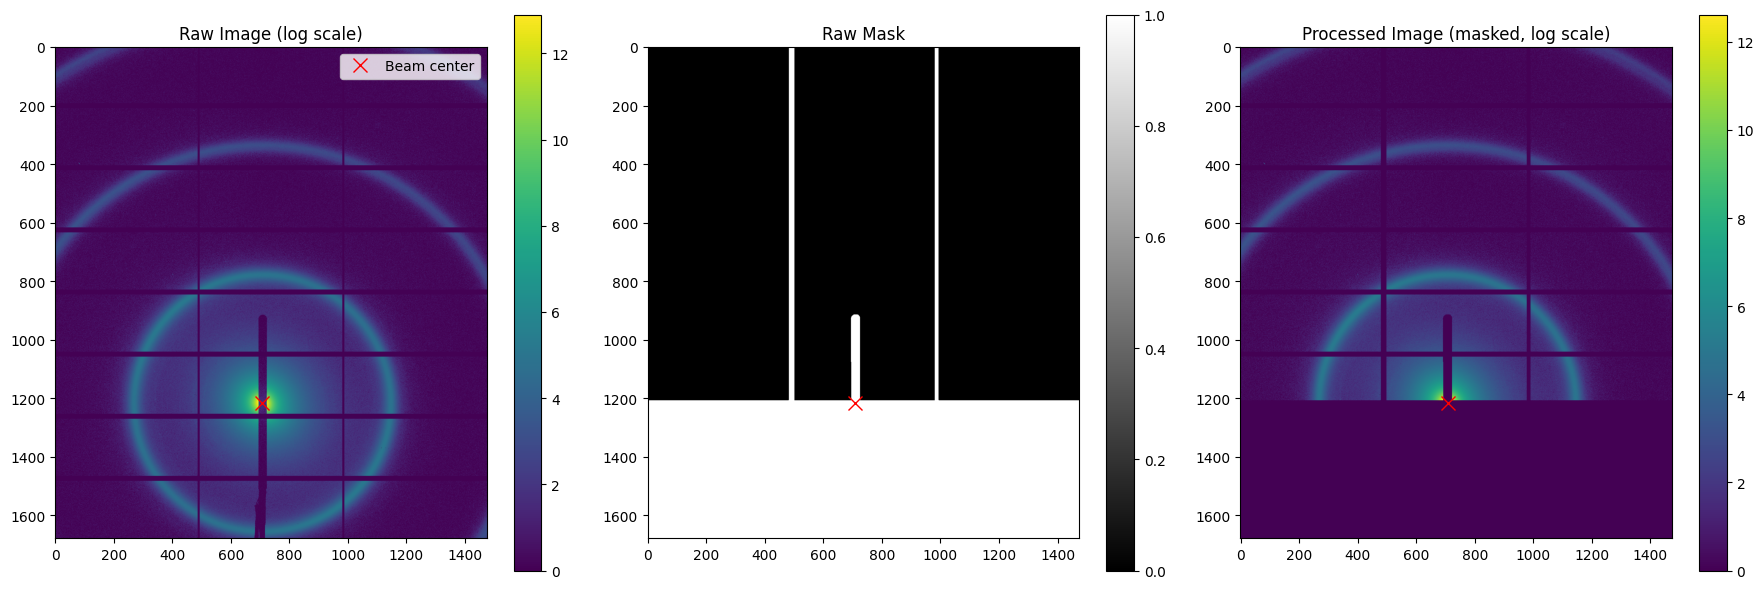

In [4]:
beam_region_mask = raw_mask[beam_center_y - 10 : beam_center_y + 10, beam_center_x - 10 : beam_center_x + 10]

detector_mask = np.copy(raw_mask)
processed_image, pyFAI_mask = get_processed_image(raw_image, detector_mask)
print(f"Processed image shape: {processed_image.shape}, dtype: {processed_image.dtype}")
print(f"NaN count: {np.isnan(processed_image).sum()} ({100*np.isnan(processed_image).sum()/processed_image.size:.1f}%)")
print(f"pyFAI mask: 0=valid ({(pyFAI_mask==0).sum()} pixels), 1=masked ({(pyFAI_mask==1).sum()} pixels)")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

im0 = axes[0].imshow(np.log1p(np.maximum(raw_image, 0)), cmap="viridis")
axes[0].set_title("Raw Image (log scale)")
axes[0].plot(beam_center_x, beam_center_y, "rx", markersize=10, label="Beam center")
axes[0].legend()
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(raw_mask, cmap="gray")
axes[1].plot(beam_center_x, beam_center_y, "rx", markersize=10, label="Beam center")
axes[1].set_title("Raw Mask")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(np.log1p(np.nan_to_num(processed_image, nan=0)), cmap="viridis")
axes[2].plot(beam_center_x, beam_center_y, "rx", markersize=10, label="Beam center")
axes[2].set_title("Processed Image (masked, log scale)")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

## SAXS Q-Space Tests


q_x shape: (1679, 1475), range: [-1.7377, 1.8831] nm^-1
q_y shape: (1679, 1475), range: [-1.1301, 2.9897] nm^-1

Sign convention check:
  q_y at row 0 (top): 2.9897 nm^-1
  q_y at beam row (1218): 0.0002 nm^-1
  q_y at bottom row: -1.1301 nm^-1
  q_x at beam col (707): -0.0010 nm^-1

pyFAI check:
  Max diff qx: 0.00e+00 nm^-1
  Max diff qy: 0.00e+00 nm^-1


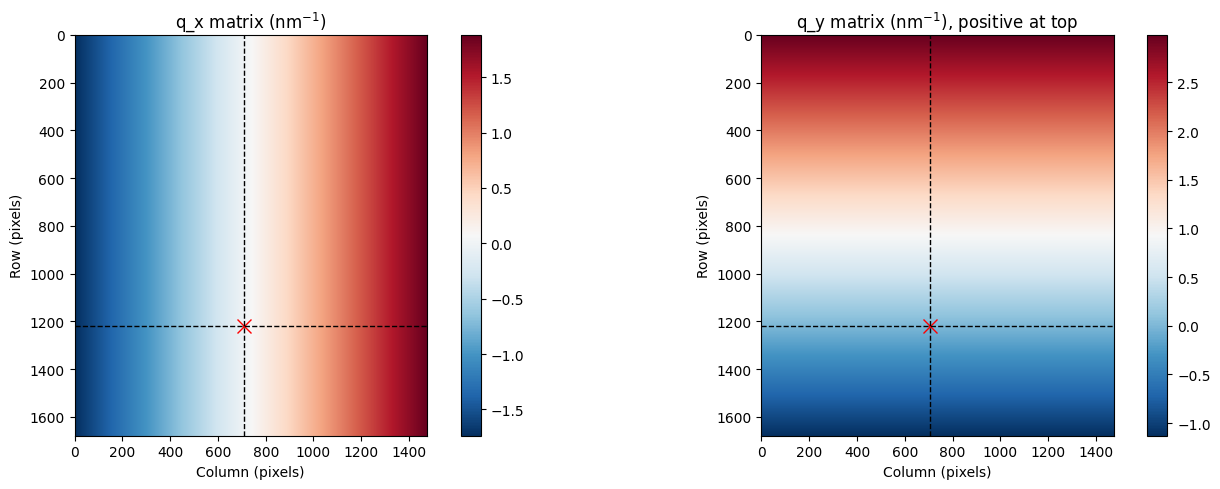

In [5]:
from pyFAI.integrator.azimuthal import AzimuthalIntegrator

q_x_matrix, q_y_matrix = compute_saxs_q_matrices(
    image_shape=processed_image.shape,
    calibration=calibration,
    invert_qy=True,
)

print(f"q_x shape: {q_x_matrix.shape}, range: [{q_x_matrix.min():.4f}, {q_x_matrix.max():.4f}] nm^-1")
print(f"q_y shape: {q_y_matrix.shape}, range: [{q_y_matrix.min():.4f}, {q_y_matrix.max():.4f}] nm^-1")

print("\nSign convention check:")
print(f"  q_y at row 0 (top): {q_y_matrix[0, q_y_matrix.shape[1]//2]:.4f} nm^-1")
print(f"  q_y at beam row ({beam_center_y}): {q_y_matrix[int(beam_center_y), q_y_matrix.shape[1]//2]:.4f} nm^-1")
print(f"  q_y at bottom row: {q_y_matrix[-1, q_y_matrix.shape[1]//2]:.4f} nm^-1")
print(f"  q_x at beam col ({beam_center_x}): {q_x_matrix[q_x_matrix.shape[0]//2, int(beam_center_x)]:.4f} nm^-1")


ai_check = AzimuthalIntegrator()
ai_check.setFit2D(
    directDist=calibration["sample_detector_distance"],
    centerX=calibration["beam_center_x"],
    centerY=calibration["beam_center_y"],
    tilt=0.0,
    tiltPlanRotation=0.0,
    pixelX=calibration["pixel_size_x"],
    pixelY=calibration["pixel_size_y"],
    wavelength=calibration["wavelength"],
)
qx_check = ai_check.array_from_unit(shape=processed_image.shape, unit="qx_nm^-1")
qy_check = -ai_check.array_from_unit(shape=processed_image.shape, unit="qy_nm^-1")

print("\npyFAI check:")
print(f"  Max diff qx: {np.max(np.abs(q_x_matrix - qx_check)):.2e} nm^-1")
print(f"  Max diff qy: {np.max(np.abs(q_y_matrix - qy_check)):.2e} nm^-1")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im0 = axes[0].imshow(q_x_matrix, cmap="RdBu_r", aspect="equal")
axes[0].plot(beam_center_x, beam_center_y, "rx", markersize=10, label="Beam center")
axes[0].axvline(beam_center_x, color="k", linestyle="--", linewidth=1)
axes[0].axhline(beam_center_y, color="k", linestyle="--", linewidth=1)
axes[0].set_title("q_x matrix (nm$^{-1}$)")
axes[0].set_xlabel("Column (pixels)")
axes[0].set_ylabel("Row (pixels)")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(q_y_matrix, cmap="RdBu_r", aspect="equal")
axes[1].plot(beam_center_x, beam_center_y, "rx", markersize=10, label="Beam center")
axes[1].axvline(beam_center_x, color="k", linestyle="--", linewidth=1)
axes[1].axhline(beam_center_y, color="k", linestyle="--", linewidth=1)
axes[1].set_title("q_y matrix (nm$^{-1}$), positive at top")
axes[1].set_xlabel("Column (pixels)")
axes[1].set_ylabel("Row (pixels)")
plt.colorbar(im1, ax=axes[1])
plt.tight_layout()
plt.show()

Target qy: 0.1500, Pixel row: 1157, Actual qy at col: 0.1501
Width 0.1 nm^-1 = 40 pixels


/data/lbnl-codes/react_gui_multimodal/backend/src/xscattering_backend/utils/linecut_extraction.py:151: RuntimeWarning: Mean of empty slice
  intensities = np.nanmean(slice_data, axis=0)


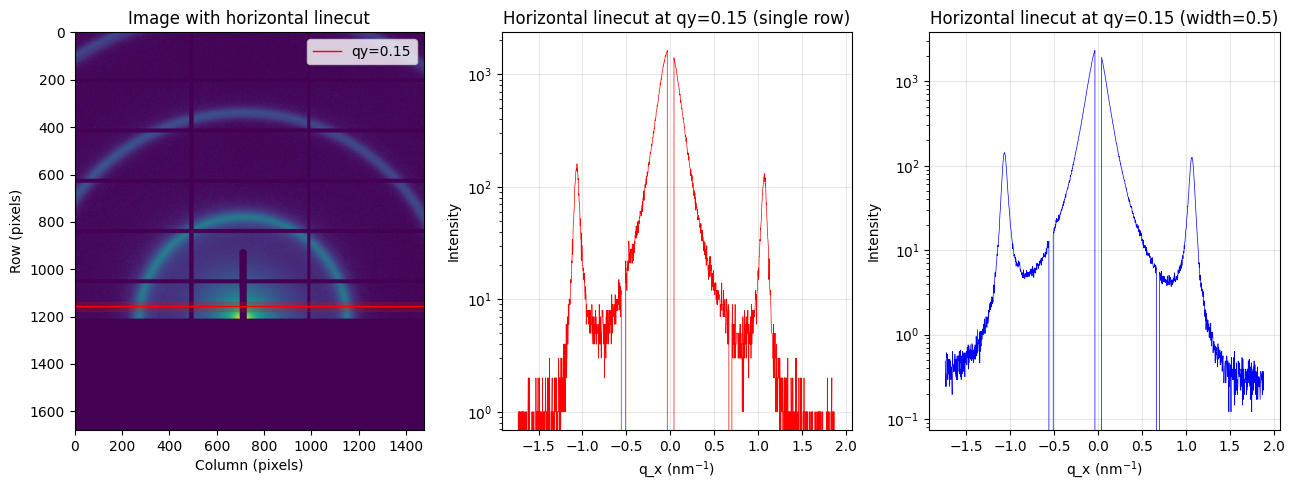

In [6]:
# SAXS horizontal linecut
target_qy = 0.15
q_vals_h, intensities_h = extract_horizontal_linecut(
    processed_image, q_x_matrix, q_y_matrix, position=target_qy, width=0.0
)

# Find pixel row for this qy
pixel_row = find_pixel_position_for_q_value(target_qy, q_y_matrix, "horizontal")
actual_qy = q_y_matrix[pixel_row, q_y_matrix.shape[1] // 2]
print(f"Target qy: {target_qy:.4f}, Pixel row: {pixel_row}, Actual qy at col: {actual_qy:.4f}")

# Test with width
target_width = 0.1
q_vals_hw, intensities_hw = extract_horizontal_linecut(
    processed_image, q_x_matrix, q_y_matrix, position=target_qy, width=target_width
)
pixel_width = calculate_q_to_pixel_width(target_qy, target_width, q_y_matrix, "horizontal")
print(f"Width {target_width} nm^-1 = {pixel_width} pixels")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

# Image with linecut overlay
axes[0].imshow(np.log1p(np.nan_to_num(processed_image, nan=0)), cmap="viridis", aspect="equal")
axes[0].axhline(y=pixel_row, color="r", linewidth=1, label=f"qy={target_qy:.2f}")
if pixel_width > 0:
    axes[0].axhspan(pixel_row - pixel_width // 2, pixel_row + pixel_width // 2, alpha=0.2, color="red")
axes[0].set_title("Image with horizontal linecut")
axes[0].set_xlabel("Column (pixels)")
axes[0].set_ylabel("Row (pixels)")
axes[0].legend()

# Single-row linecut
axes[1].plot(q_vals_h, intensities_h, "r-", linewidth=0.5)
axes[1].set_xlabel("q_x (nm$^{-1}$)")
axes[1].set_ylabel("Intensity")
axes[1].set_title(f"Horizontal linecut at qy={target_qy:.2f} (single row)")
axes[1].set_yscale("log")
axes[1].grid(True, alpha=0.3)

# Width-averaged linecut
axes[2].plot(q_vals_hw, intensities_hw, "b-", linewidth=0.5)
axes[2].set_xlabel("q_x (nm$^{-1}$)")
axes[2].set_ylabel("Intensity")
axes[2].set_title(f"Horizontal linecut at qy={target_qy:.2f} (width=0.5)")
axes[2].set_yscale("log")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Target qx: 0.2000, Pixel col: 789, Actual qx at row: 0.2006
Width 0.1 nm^-1 = 41 pixels


/data/lbnl-codes/react_gui_multimodal/backend/src/xscattering_backend/utils/linecut_extraction.py:196: RuntimeWarning: Mean of empty slice
  intensities = np.nanmean(slice_data, axis=1)


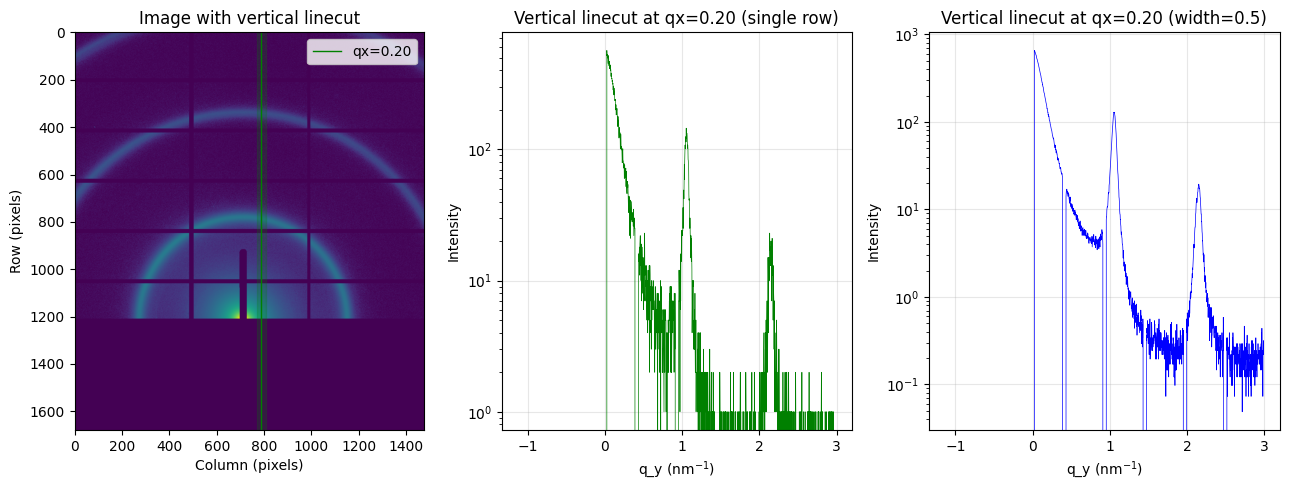

In [7]:
# SAXS vertical linecut
target_qx = 0.2
q_vals_v, intensities_v = extract_vertical_linecut(
    processed_image, q_x_matrix, q_y_matrix, position=target_qx, width=0.0
)

# Find pixel column for this qx
pixel_col = find_pixel_position_for_q_value(target_qx, q_x_matrix, "vertical")
actual_qx = q_x_matrix[q_x_matrix.shape[0] // 2, pixel_col]
print(f"Target qx: {target_qx:.4f}, Pixel col: {pixel_col}, Actual qx at row: {actual_qx:.4f}")

# Test with width
target_width = 0.1
q_vals_vw, intensities_vw = extract_vertical_linecut(
    processed_image, q_x_matrix, q_y_matrix, position=target_qx, width=target_width
)
pixel_width = calculate_q_to_pixel_width(target_qx, target_width, q_x_matrix, "vertical")
print(f"Width {target_width} nm^-1 = {pixel_width} pixels")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

# Image with linecut overlay
axes[0].imshow(np.log1p(np.nan_to_num(processed_image, nan=0)), cmap="viridis", aspect="equal")
axes[0].axvline(x=pixel_col, color="g", linewidth=1, label=f"qx={target_qx:.2f}")
if pixel_width > 0:
    axes[0].axvspan(pixel_col - pixel_width // 2, pixel_col + pixel_width // 2, alpha=0.2, color="green")
axes[0].set_title("Image with vertical linecut")
axes[0].set_xlabel("Column (pixels)")
axes[0].set_ylabel("Row (pixels)")
axes[0].legend()

# Single-row linecut
axes[1].plot(q_vals_v, intensities_v, "g-", linewidth=0.5)
axes[1].set_xlabel("q_y (nm$^{-1}$)")
axes[1].set_ylabel("Intensity")
axes[1].set_title(f"Vertical linecut at qx={target_qx:.2f} (single row)")
axes[1].set_yscale("log")
axes[1].grid(True, alpha=0.3)

# Width-averaged linecut
axes[2].plot(q_vals_vw, intensities_vw, "b-", linewidth=0.5)
axes[2].set_xlabel("q_y (nm$^{-1}$)")
axes[2].set_ylabel("Intensity")
axes[2].set_title(f"Vertical linecut at qx={target_qx:.2f} (width=0.5)")
axes[2].set_yscale("log")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Full integration: q=[0.0425, 3.5314] nm^-1, 1679 points


Upper quadrant [-90°, 0°]: 1679 points
Right quadrant [0°, 90°]: 1679 points

Q-array range: [0.0010, 3.5307] nm^-1
Chi-array range: [-180.0, 179.9] deg


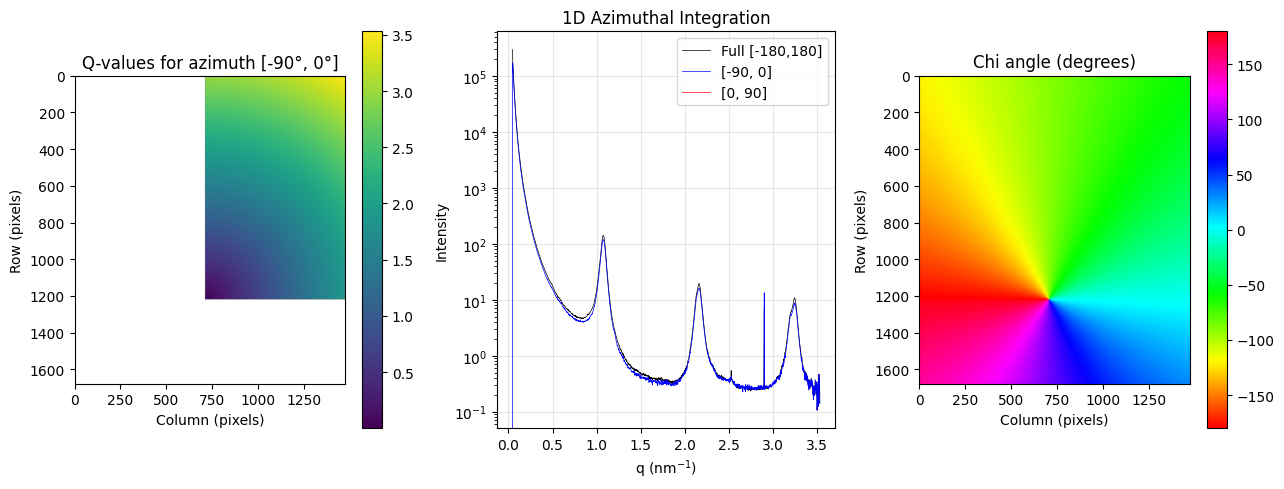

In [8]:
# SAXS azimuthal integration

ai = create_azimuthal_integrator(
    sample_detector_distance=calibration["sample_detector_distance"],
    beam_center_x=calibration["beam_center_x"],
    beam_center_y=calibration["beam_center_y"],
    pixel_size_x=calibration["pixel_size_x"],
    pixel_size_y=calibration["pixel_size_y"],
    wavelength=calibration["wavelength"],
)

# Full azimuthal integration
q_full, I_full = integrate_1d(ai, processed_image, azimuth_range=(-180, 180), mask=pyFAI_mask)
print(f"Full integration: q=[{q_full.min():.4f}, {q_full.max():.4f}] nm^-1, {len(q_full)} points")

# Restricted azimuth ranges
q_upper, I_upper = integrate_1d(ai, processed_image, azimuth_range=(-90, 0), mask=pyFAI_mask)
q_right, I_right = integrate_1d(ai, processed_image, azimuth_range=(0, 90), mask=pyFAI_mask)

print(f"Upper quadrant [-90°, 0°]: {len(q_upper)} points")
print(f"Right quadrant [0°, 90°]: {len(q_right)} points")

# Verify chi array for overlay
q_array = ai.qArray(processed_image.shape)
chi_array = ai.center_array(processed_image.shape, unit="chi_rad")
print(f"\nQ-array range: [{q_array.min():.4f}, {q_array.max():.4f}] nm^-1")
print(f"Chi-array range: [{np.degrees(chi_array.min()):.1f}, {np.degrees(chi_array.max()):.1f}] deg")

# Create azimuth mask for visualization
az_mask = (chi_array >= np.radians(-90)) & (chi_array <= np.radians(0))
q_filtered = np.where(az_mask, q_array, np.nan)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(13, 5))

im0 = axes[0].imshow(q_filtered, cmap="viridis", aspect="equal")
axes[0].set_title("Q-values for azimuth [-90°, 0°]")
axes[0].set_xlabel("Column (pixels)")
axes[0].set_ylabel("Row (pixels)")
plt.colorbar(im0, ax=axes[0])

axes[1].plot(q_full, I_full, "k-", linewidth=0.5, label="Full [-180,180]")
axes[1].plot(q_upper, I_upper, "b-", linewidth=0.5, label="[-90, 0]")
axes[1].plot(q_right, I_right, "r-", linewidth=0.5, label="[0, 90]")
axes[1].set_xlabel("q (nm$^{-1}$)")
axes[1].set_ylabel("Intensity")
axes[1].set_title("1D Azimuthal Integration")
axes[1].set_yscale("log")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

im2 = axes[2].imshow(np.degrees(chi_array), cmap="hsv", aspect="equal")
axes[2].set_title("Chi angle (degrees)")
axes[2].set_xlabel("Column (pixels)")
axes[2].set_ylabel("Row (pixels)")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

## GISAXS Q-Space Tests


Transformed image shape: (1679, 1475)
qip range: [-1.7377, 1.8827] nm^-1
qoop range: [0.0256, 2.9873] nm^-1
NaN fraction (missing wedge): 36.01%

Sign convention check:
  qoop_values[0] (top of image): 2.9873 (should be positive and higher)
  qoop_values[-1] (bottom of image): 0.0256 (should be low)
  qoop_values is decreasing (expected: decreasing)

Pixel-space Q matrices:
  qip_pixel shape: (1679, 1475)
  qoop_pixel shape: (1679, 1475)
  qoop at row 0 (top): 2.9882 (should be positive)
  qoop at beam center: 0.0002 nm^-1


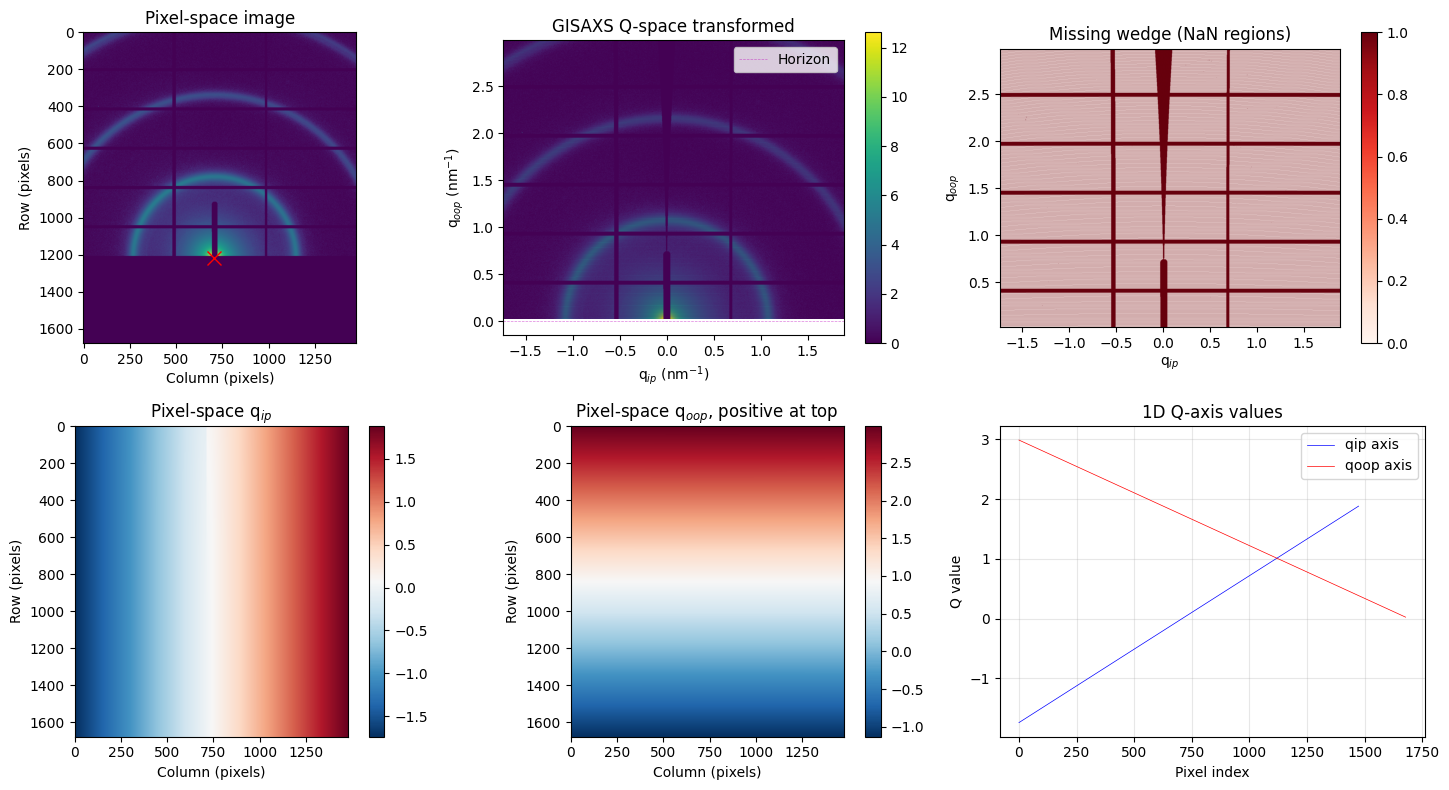

In [9]:
# GISAXS Q-space transformation

gisaxs_calibration = calibration.copy()

gisaxs_result = transform_gisaxs_to_qspace(
    image_array=processed_image,
    calibration=gisaxs_calibration,
    mask=pyFAI_mask,
)

print(f"Transformed image shape: {gisaxs_result.transformed_image.shape}")
print(f"qip range: [{gisaxs_result.qip_values.min():.4f}, {gisaxs_result.qip_values.max():.4f}] nm^-1")
print(f"qoop range: [{gisaxs_result.qoop_values.min():.4f}, {gisaxs_result.qoop_values.max():.4f}] nm^-1")
nan_fraction = np.isnan(gisaxs_result.transformed_image).sum() / gisaxs_result.transformed_image.size
print(f"NaN fraction (missing wedge): {nan_fraction:.2%}")

# Verify sign convention: qoop should be positive at top (index 0) after display convention
print("\nSign convention check:")
print(f"  qoop_values[0] (top of image): {gisaxs_result.qoop_values[0]:.4f} (should be positive and higher)")
print(f"  qoop_values[-1] (bottom of image): {gisaxs_result.qoop_values[-1]:.4f} (should be low)")
trend = "decreasing" if gisaxs_result.qoop_values[0] > gisaxs_result.qoop_values[-1] else "increasing"
print(f"  qoop_values is {trend} (expected: decreasing)")

# Verify pixel-space Q matrices
print("\nPixel-space Q matrices:")
print(f"  qip_pixel shape: {gisaxs_result.qip_pixel_matrix.shape}")
print(f"  qoop_pixel shape: {gisaxs_result.qoop_pixel_matrix.shape}")
print(
    f"  qoop at row 0 (top): {gisaxs_result.qoop_pixel_matrix[0, gisaxs_result.qoop_pixel_matrix.shape[1]//2]:.4f} (should be positive)"
)
print(f"  qoop at beam center: {gisaxs_result.qoop_pixel_matrix[beam_center_y, beam_center_x]:.4f} nm^-1")

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Row 1: Images
axes[0, 0].imshow(np.log1p(np.nan_to_num(processed_image, nan=0)), cmap="viridis", aspect="equal")
axes[0, 0].set_title("Pixel-space image")
axes[0, 0].plot(beam_center_x, beam_center_y, "rx", markersize=10)
axes[0, 0].set_xlabel("Column (pixels)")
axes[0, 0].set_ylabel("Row (pixels)")

im01 = axes[0, 1].imshow(
    np.log1p(np.nan_to_num(gisaxs_result.transformed_image, nan=0)),
    extent=[
        gisaxs_result.qip_values.min(),
        gisaxs_result.qip_values.max(),
        gisaxs_result.qoop_values.min(),
        gisaxs_result.qoop_values.max(),
    ],
    aspect="equal",
    cmap="viridis",
    origin="upper",
)
axes[0, 1].set_xlabel("q$_{ip}$ (nm$^{-1}$)")
axes[0, 1].set_ylabel("q$_{oop}$ (nm$^{-1}$)")
axes[0, 1].set_title("GISAXS Q-space transformed")
axes[0, 1].axhline(y=0, color="m", linewidth=0.5, linestyle="--", alpha=0.5, label="Horizon")
axes[0, 1].legend()
plt.colorbar(im01, ax=axes[0, 1])

# Missing wedge visualization
missing = np.isnan(gisaxs_result.transformed_image).astype(float)
im02 = axes[0, 2].imshow(
    missing,
    cmap="Reds",
    aspect="equal",
    extent=[
        gisaxs_result.qip_values.min(),
        gisaxs_result.qip_values.max(),
        gisaxs_result.qoop_values.min(),
        gisaxs_result.qoop_values.max(),
    ],
    origin="upper",
)
axes[0, 2].set_title("Missing wedge (NaN regions)")
axes[0, 2].set_xlabel("q$_{ip}$")
axes[0, 2].set_ylabel("q$_{oop}$")
plt.colorbar(im02, ax=axes[0, 2])

# Pixel-space Q matrices
im10 = axes[1, 0].imshow(gisaxs_result.qip_pixel_matrix, cmap="RdBu_r", aspect="equal")
axes[1, 0].set_title("Pixel-space q$_{ip}$")
axes[1, 0].set_xlabel("Column (pixels)")
axes[1, 0].set_ylabel("Row (pixels)")
plt.colorbar(im10, ax=axes[1, 0])

im11 = axes[1, 1].imshow(gisaxs_result.qoop_pixel_matrix, cmap="RdBu_r", aspect="equal")
axes[1, 1].set_title("Pixel-space q$_{oop}$, positive at top")
axes[1, 1].set_xlabel("Column (pixels)")
axes[1, 1].set_ylabel("Row (pixels)")
plt.colorbar(im11, ax=axes[1, 1])

# 1D axis values
axes[1, 2].plot(gisaxs_result.qip_values, label="qip axis", color="blue", linewidth=0.5)
axes[1, 2].plot(gisaxs_result.qoop_values, label="qoop axis", color="red", linewidth=0.5)
axes[1, 2].set_xlabel("Pixel index")
axes[1, 2].set_ylabel("Q value")
axes[1, 2].set_title("1D Q-axis values")
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Horizontal linecut at qoop=0.2: qip=[-1.7377, 1.8827], max_I=554.8
Horizontal linecut at qoop=1.0: qip=[-1.7377, 1.8827], max_I=139.5
Horizontal linecut at qoop=1.5: qip=[-1.7377, 1.8827], max_I=24.7


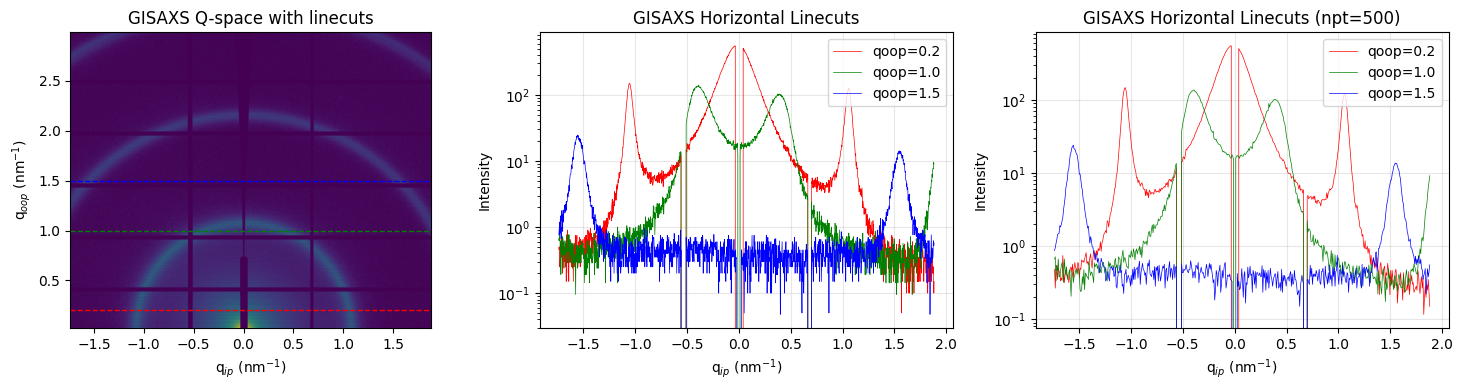

In [10]:
# GISAXS horizontal linecut (pyFAI)

qoop_positions = [0.2, 1.0, 1.5]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(
    np.log1p(np.nan_to_num(gisaxs_result.transformed_image, nan=0)),
    extent=[
        gisaxs_result.qip_values.min(),
        gisaxs_result.qip_values.max(),
        gisaxs_result.qoop_values.min(),
        gisaxs_result.qoop_values.max(),
    ],
    aspect="equal",
    cmap="viridis",
    origin="upper",
)
axes[0].set_title("GISAXS Q-space with linecuts")

colors = ["r", "g", "b"]
for i, qoop_pos in enumerate(qoop_positions):
    qip_vals, intensity = extract_gisaxs_horizontal_linecut_pyfai(
        processed_image, pyFAI_mask, gisaxs_calibration, qoop_position=qoop_pos, qoop_width=0.05
    )
    qip_vals_npt, intensity_npt = extract_gisaxs_horizontal_linecut_pyfai(
        processed_image, pyFAI_mask, gisaxs_calibration, qoop_position=qoop_pos, qoop_width=0.05, npt=500
    )
    axes[0].axhline(y=qoop_pos, color=colors[i], linewidth=1, linestyle="--")
    axes[1].plot(qip_vals, intensity, color=colors[i], linewidth=0.5, label=f"qoop={qoop_pos:.1f}")
    axes[2].plot(qip_vals_npt, intensity_npt, color=colors[i], linewidth=0.5, label=f"qoop={qoop_pos:.1f}")
    print(
        f"Horizontal linecut at qoop={qoop_pos}: qip=[{qip_vals.min():.4f}, {qip_vals.max():.4f}], max_I={intensity.max():.1f}"
    )

axes[0].set_xlabel("q$_{ip}$ (nm$^{-1}$)")
axes[0].set_ylabel("q$_{oop}$ (nm$^{-1}$)")
axes[1].set_xlabel("q$_{ip}$ (nm$^{-1}$)")
axes[1].set_ylabel("Intensity")
axes[1].set_title("GISAXS Horizontal Linecuts")
axes[1].set_yscale("log")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[2].set_xlabel("q$_{ip}$ (nm$^{-1}$)")
axes[2].set_ylabel("Intensity")
axes[2].set_title("GISAXS Horizontal Linecuts (npt=500)")
axes[2].set_yscale("log")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Vertical linecut at qip=-1.0: qoop=[0.0256, 2.9873], max_I=163.1
Vertical linecut at qip=0.0: qoop=[0.0256, 2.9873], max_I=184737.9
Vertical linecut at qip=1.0: qoop=[0.0256, 2.9873], max_I=100.2


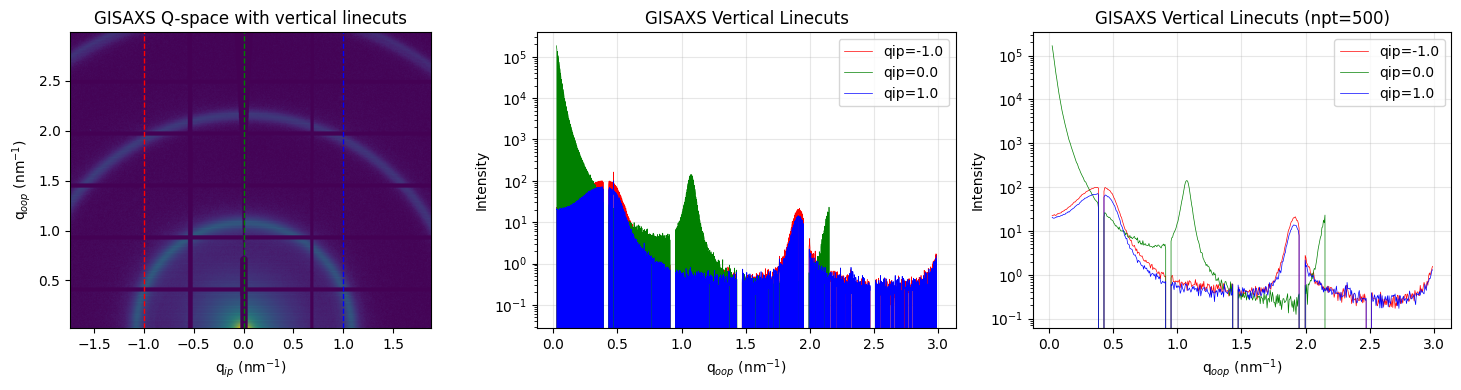

In [11]:
# GISAXS vertical linecut (pyFAI)

qip_positions = [-1.0, 0.0, 1.0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(
    np.log1p(np.nan_to_num(gisaxs_result.transformed_image, nan=0)),
    extent=[
        gisaxs_result.qip_values.min(),
        gisaxs_result.qip_values.max(),
        gisaxs_result.qoop_values.min(),
        gisaxs_result.qoop_values.max(),
    ],
    aspect="equal",
    cmap="viridis",
    origin="upper",
)
axes[0].set_title("GISAXS Q-space with vertical linecuts")

colors = ["r", "g", "b"]
for i, qip_pos in enumerate(qip_positions):
    qoop_vals, intensity = extract_gisaxs_vertical_linecut_pyfai(
        processed_image, pyFAI_mask, gisaxs_calibration, qip_position=qip_pos, qip_width=0.10
    )
    qoop_vals_npt, intensity_npt = extract_gisaxs_vertical_linecut_pyfai(
        processed_image, pyFAI_mask, gisaxs_calibration, qip_position=qip_pos, qip_width=0.10, npt=500
    )
    axes[0].axvline(x=qip_pos, color=colors[i], linewidth=1, linestyle="--")
    axes[1].plot(qoop_vals, intensity, color=colors[i], linewidth=0.5, label=f"qip={qip_pos:.1f}")
    axes[2].plot(qoop_vals_npt, intensity_npt, color=colors[i], linewidth=0.5, label=f"qip={qip_pos:.1f}")
    print(
        f"Vertical linecut at qip={qip_pos}: qoop=[{qoop_vals.min():.4f}, {qoop_vals.max():.4f}], max_I={intensity.max():.1f}"
    )

axes[0].set_xlabel("q$_{ip}$ (nm$^{-1}$)")
axes[0].set_ylabel("q$_{oop}$ (nm$^{-1}$)")
axes[1].set_xlabel("q$_{oop}$ (nm$^{-1}$)")
axes[1].set_ylabel("Intensity")
axes[1].set_title("GISAXS Vertical Linecuts")
axes[1].set_yscale("log")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[2].set_xlabel("q$_{oop}$ (nm$^{-1}$)")
axes[2].set_ylabel("Intensity")
axes[2].set_title("GISAXS Vertical Linecuts (npt=500)")
axes[2].set_yscale("log")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Cross-Validation Tests


Target qoop: 0.8000, 2D grid closest: 0.8004
Direct integration: 1475 points
2D slice: 1475 points
Valid (non-NaN) points in 2D slice: 1437


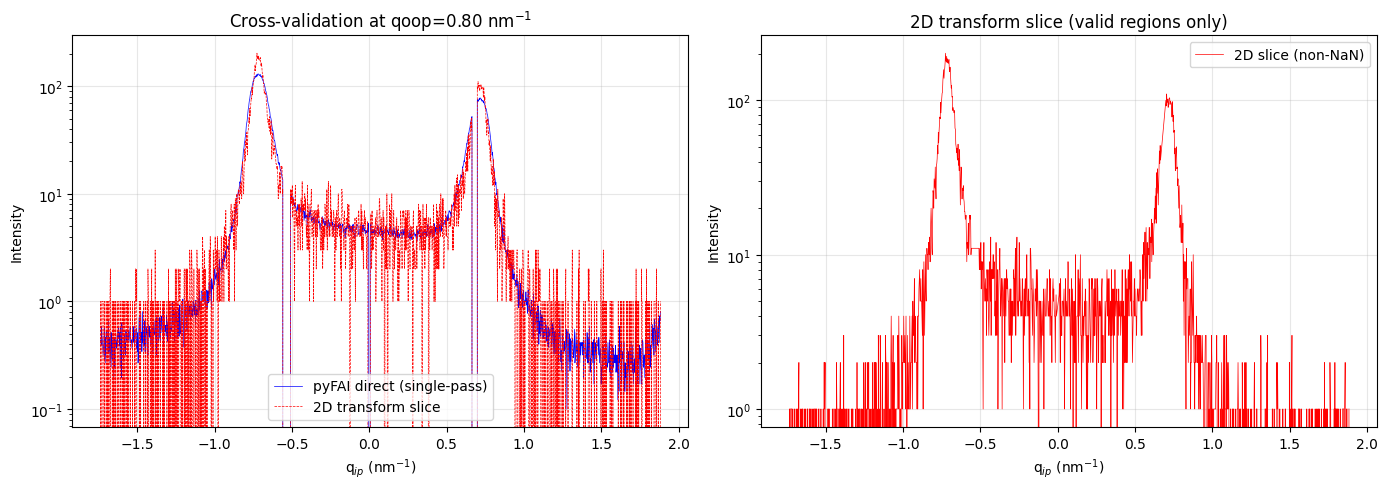

In [12]:
# Cross-validation
# Comparing pyFAI direct integration vs slicing the 2D transform

qoop_test = 0.8

# Method 1: pyFAI direct
qip_direct, I_direct = extract_gisaxs_horizontal_linecut_pyfai(
    processed_image, pyFAI_mask, gisaxs_calibration, qoop_position=qoop_test, qoop_width=0.10
)

# Method 2: Slice from 2D transform
qoop_idx = np.argmin(np.abs(gisaxs_result.qoop_values - qoop_test))
actual_qoop = gisaxs_result.qoop_values[qoop_idx]
I_slice = gisaxs_result.transformed_image[qoop_idx, :]
qip_slice = gisaxs_result.qip_values

print(f"Target qoop: {qoop_test:.4f}, 2D grid closest: {actual_qoop:.4f}")
print(f"Direct integration: {len(qip_direct)} points")
print(f"2D slice: {len(qip_slice)} points")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(qip_direct, I_direct, "b-", linewidth=0.5, label="pyFAI direct (single-pass)")
axes[0].plot(qip_slice, np.nan_to_num(I_slice, nan=0), "r--", linewidth=0.5, label="2D transform slice")
axes[0].set_xlabel("q$_{ip}$ (nm$^{-1}$)")
axes[0].set_ylabel("Intensity")
axes[0].set_title(f"Cross-validation at qoop={qoop_test:.2f} nm$^{{-1}}$")
axes[0].set_yscale("log")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Zoom into region with good coverage
valid_slice = ~np.isnan(I_slice)
if valid_slice.sum() > 0:
    axes[1].plot(qip_slice[valid_slice], I_slice[valid_slice], "r-", linewidth=0.5, label="2D slice (non-NaN)")
    axes[1].set_xlabel("q$_{ip}$ (nm$^{-1}$)")
    axes[1].set_ylabel("Intensity")
    axes[1].set_title("2D transform slice (valid regions only)")
    axes[1].set_yscale("log")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    print(f"Valid (non-NaN) points in 2D slice: {valid_slice.sum()}")

plt.tight_layout()
plt.show()

In [13]:
# Pixel-Q consistency check

# SAXS: Check that pixel<->Q mapping is self-consistent
print("\n--- SAXS Pixel-Q Consistency ---")
test_qy_values = [-1.0, -0.5, 0.0, 0.5, 1.0]
center_col = q_y_matrix.shape[1] // 2

for target_qy in test_qy_values:
    row = find_pixel_position_for_q_value(target_qy, q_y_matrix, "horizontal")
    actual_qy = q_y_matrix[row, center_col]
    diff = abs(actual_qy - target_qy)
    print(f"  target qy={target_qy:+.2f} -> row={row:4d}, actual qy={actual_qy:+.4f}, diff={diff:.4f} nm^-1")

beam_center_y, beam_center_x = int(calibration["beam_center_y"]), int(calibration["beam_center_x"])
print(f"\n  At beam center pixel ({beam_center_y}, {beam_center_x}):")
print(f"    qx = {q_x_matrix[beam_center_y, beam_center_x]:.6f} nm^-1")
print(f"    qy = {q_y_matrix[beam_center_y, beam_center_x]:.6f} nm^-1")

# GISAXS: Check pixel-space Q matrices at beam center
print("\n--- GISAXS Pixel-Q Consistency ---")
qip_at_beam = gisaxs_result.qip_pixel_matrix[beam_center_y, beam_center_x]
qoop_at_beam = gisaxs_result.qoop_pixel_matrix[beam_center_y, beam_center_x]


print("  At beam center:")
print(f"    qip = {qip_at_beam:.6f} nm^-1")
print(f"    qoop = {qoop_at_beam:.6f} nm^-1")

# Check Q-grid uniformity
dq_ip = np.diff(gisaxs_result.qip_values)
dq_oop = np.diff(gisaxs_result.qoop_values)
print("\n  Q-grid uniformity:")
print(f"    dq_ip: mean={dq_ip.mean():.6f}, std={dq_ip.std():.2e}")
print(f"    dq_oop: mean={dq_oop.mean():.6f}, std={dq_oop.std():.2e}")


--- SAXS Pixel-Q Consistency ---
  target qy=-1.00 -> row=1625, actual qy=-0.9999, diff=0.0001 nm^-1
  target qy=-0.50 -> row=1422, actual qy=-0.5011, diff=0.0011 nm^-1
  target qy=+0.00 -> row=1218, actual qy=+0.0002, diff=0.0002 nm^-1
  target qy=+0.50 -> row=1015, actual qy=+0.4991, diff=0.0009 nm^-1
  target qy=+1.00 -> row= 811, actual qy=+1.0003, diff=0.0003 nm^-1

  At beam center pixel (1218, 707):
    qx = -0.000956 nm^-1
    qy = 0.000221 nm^-1

--- GISAXS Pixel-Q Consistency ---
  At beam center:
    qip = -0.000956 nm^-1
    qoop = 0.000221 nm^-1

  Q-grid uniformity:
    dq_ip: mean=0.002456, std=6.23e-17
    dq_oop: mean=-0.001765, std=1.79e-16


Difference between manual and pyFAI calculations:
  qip: max=0.094453 nm^-1, mean=0.002411
  qoop: max=0.002278 nm^-1, mean=0.000331


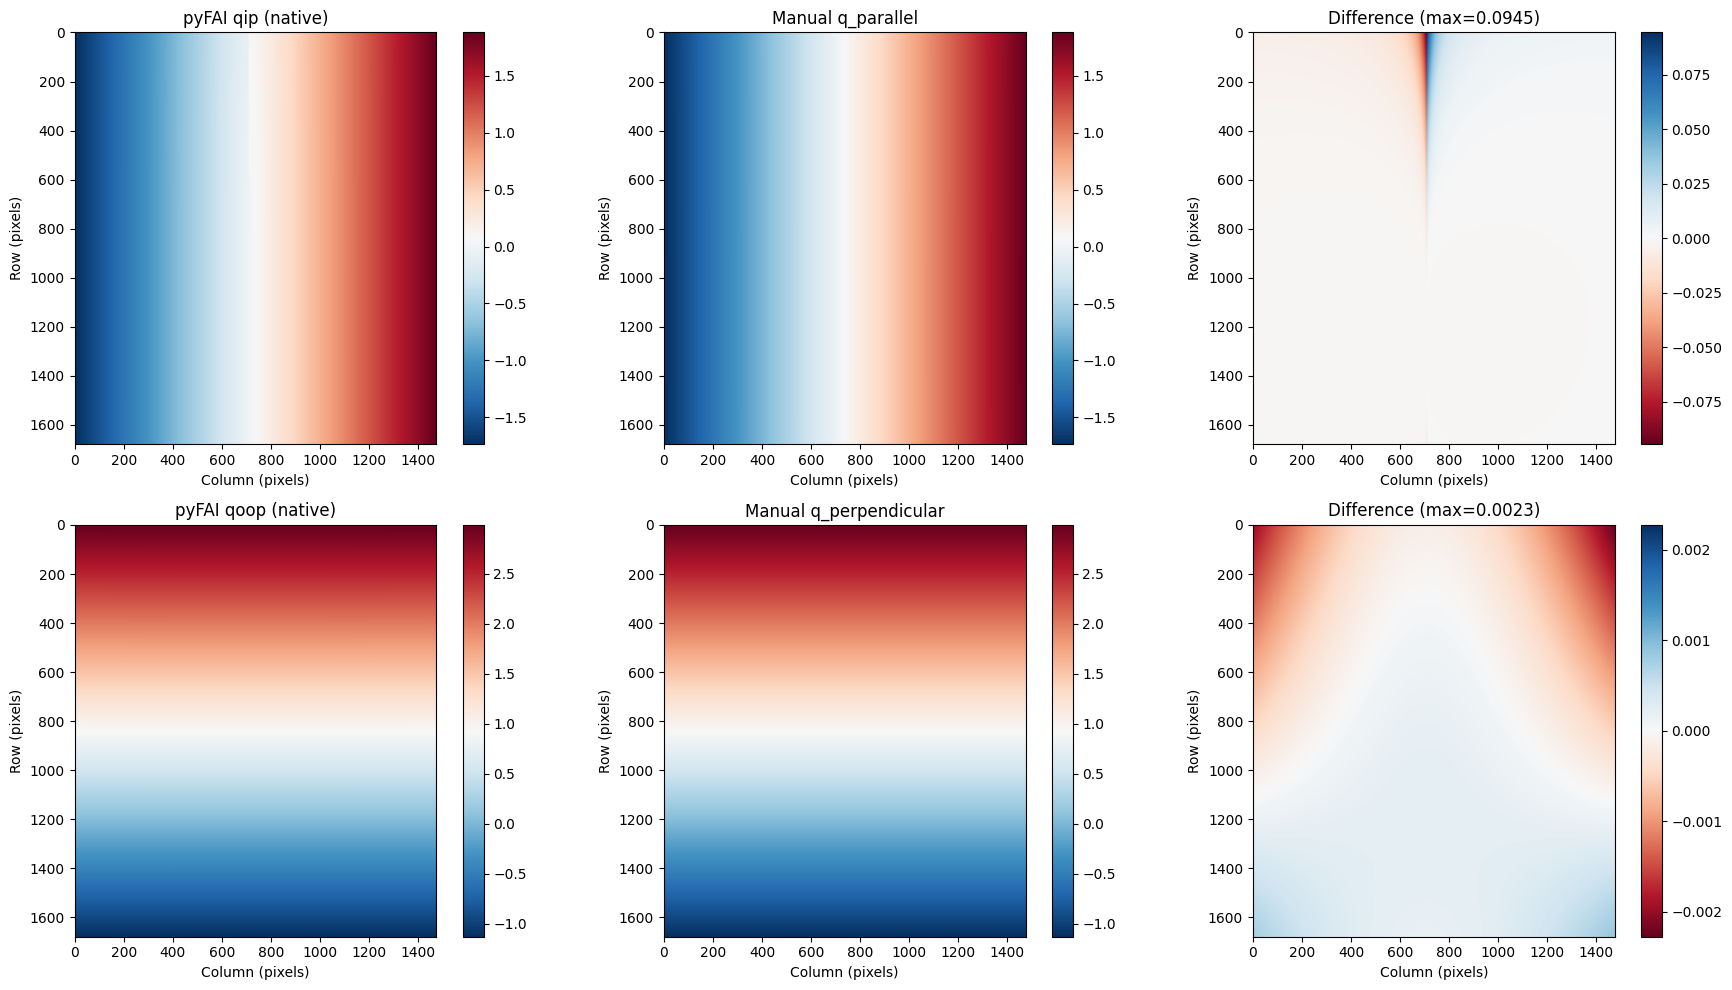

In [14]:
# Manual GISAXS Q calculation vs pyFAI
from pyFAI import units

# Manual GISAXS Q-vector computation from first principles
wavelength_nm = calibration["wavelength"] * 0.1  # Angstrom -> nm
k = 2 * np.pi / wavelength_nm
alpha_i = np.radians(calibration["incident_angle"])

pixel_size_m = calibration["pixel_size_x"] * 1e-6  # µm -> m
det_dist_m = calibration["sample_detector_distance"] * 1e-3  # mm -> m
ny, nx = processed_image.shape

# Create detector pixel positions relative to beam center
# pyFAI convention: y = (row - centerY) * pixel, increasing downward
x_pixels = (np.arange(nx) - beam_center_x) * pixel_size_m
y_pixels = (np.arange(ny) - beam_center_y) * pixel_size_m
X, Y = np.meshgrid(x_pixels, y_pixels)

# Exit angles from detector geometry
alpha_f = np.arctan2(-Y, det_dist_m) - alpha_i
psi = np.arctan2(X, det_dist_m)

# Q components
q_perpendicular_manual = k * (np.sin(alpha_f) + np.sin(alpha_i))
q_parallel_manual = k * np.cos(alpha_f) * np.sin(psi)

# Get pyFAI pixel-space values (native convention, not display)
fi = create_fiber_integrator(gisaxs_calibration)

qip_unit = units.get_unit_fiber("qip_nm^-1")
qip_unit.incident_angle = np.radians(calibration["incident_angle"])
qip_unit.tilt_angle = 0.0
qip_unit.sample_orientation = 1
qip_pyfai = fi.array_from_unit(shape=processed_image.shape, unit=qip_unit)

qoop_unit = units.get_unit_fiber("qoop_nm^-1")
qoop_unit.incident_angle = np.radians(calibration["incident_angle"])
qoop_unit.tilt_angle = 0.0
qoop_unit.sample_orientation = 1
qoop_pyfai = -fi.array_from_unit(shape=processed_image.shape, unit=qoop_unit)

# Compare raw pyFAI vs manual (both in native convention, no negation)
diff_qip = qip_pyfai - q_parallel_manual
diff_qoop = qoop_pyfai - q_perpendicular_manual

print("Difference between manual and pyFAI calculations:")
print(f"  qip: max={np.abs(diff_qip).max():.6f} nm^-1, mean={np.abs(diff_qip).mean():.6f}")
print(f"  qoop: max={np.abs(diff_qoop).max():.6f} nm^-1, mean={np.abs(diff_qoop).mean():.6f}")

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: qip comparison
im0 = axes[0, 0].imshow(qip_pyfai, cmap="RdBu_r", aspect="equal")
axes[0, 0].set_title("pyFAI qip (native)")
axes[0, 0].set_xlabel("Column (pixels)")
axes[0, 0].set_ylabel("Row (pixels)")
plt.colorbar(im0, ax=axes[0, 0])

im1 = axes[0, 1].imshow(q_parallel_manual, cmap="RdBu_r", aspect="equal")
axes[0, 1].set_title("Manual q_parallel")
axes[0, 1].set_xlabel("Column (pixels)")
axes[0, 1].set_ylabel("Row (pixels)")
plt.colorbar(im1, ax=axes[0, 1])

vmax_qip = max(abs(diff_qip.min()), abs(diff_qip.max()))
im2 = axes[0, 2].imshow(diff_qip, cmap="RdBu", vmin=-vmax_qip, vmax=vmax_qip, aspect="equal")
axes[0, 2].set_title(f"Difference (max={vmax_qip:.4f})")
axes[0, 2].set_xlabel("Column (pixels)")
axes[0, 2].set_ylabel("Row (pixels)")
plt.colorbar(im2, ax=axes[0, 2])

# Row 2: qoop comparison
im3 = axes[1, 0].imshow(qoop_pyfai, cmap="RdBu_r", aspect="equal")
axes[1, 0].set_title("pyFAI qoop (native)")
axes[1, 0].set_xlabel("Column (pixels)")
axes[1, 0].set_ylabel("Row (pixels)")
plt.colorbar(im3, ax=axes[1, 0])

im4 = axes[1, 1].imshow(q_perpendicular_manual, cmap="RdBu_r", aspect="equal")
axes[1, 1].set_title("Manual q_perpendicular")
axes[1, 1].set_xlabel("Column (pixels)")
axes[1, 1].set_ylabel("Row (pixels)")
plt.colorbar(im4, ax=axes[1, 1])

vmax_qoop = max(abs(diff_qoop.min()), abs(diff_qoop.max()))
im5 = axes[1, 2].imshow(diff_qoop, cmap="RdBu", vmin=-vmax_qoop, vmax=vmax_qoop, aspect="equal")
axes[1, 2].set_title(f"Difference (max={vmax_qoop:.4f})")
axes[1, 2].set_xlabel("Column (pixels)")
axes[1, 2].set_ylabel("Row (pixels)")
plt.colorbar(im5, ax=axes[1, 2])

plt.tight_layout()
plt.show()